<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/23_PI_DeepONet_parameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Physics Informed Deep Neural Operators
- Based on: https://towardsdatascience.com/operator-learning-via-physics-informed-deeponet-lets-implement-it-from-scratch-6659f3179887/
- Code at: https://github.com/ShuaiGuo16/PI-DeepONet/tree/main

### Objective

In this notebook, we develop a PI-DeepONet model that can tackle inverse problems. Specifically, we investigate the following example equation:

\begin{equation}
\frac{ds(t)}{dt} = a \cdot u(t)+b, \; t \in [0, 1]
\end{equation}

with an initial condition $s(0)=0$, and our goal is to estimate unknown parameters a and b given the observed input and output functions.

### 0. Import libraries

In [1]:
#!pip install keras==2.14.0 tensorflow==2.14.0

In [2]:
# Standard library
import time
from collections import defaultdict
from pathlib import Path

# Numerical computing and data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Scientific computing
from scipy.integrate import solve_ivp

# Deep learning
import tensorflow as tf
from tensorflow import keras

# Utilities
from tqdm import tqdm

# Reproducibility
tf.random.set_seed(42)

### 1. Data generation

We use a zero-mean Gaussian Process to generate the dataset for both training and testing.

In [3]:
def generate_gp_samples(length_scale, num_samples, num_points=100, domain=(0.0, 1.0)):
    """
    Generate synthetic function samples from a Gaussian process prior.

    Parameters
    ----------
    length_scale : float
        Length scale of the RBF kernel.
    num_samples : int
        Number of function samples to generate.
    num_points : int, optional
        Number of spatial points used to discretize each function.
    domain : tuple of float, optional
        Interval over which the functions are sampled.

    Returns
    -------
    samples : np.ndarray of shape (num_samples, num_points)
        Sampled function values on the discretized domain.
    """
    # Define the evaluation grid
    x_grid = np.linspace(domain[0], domain[1], num_points).reshape(-1, 1)

    # Define Gaussian process prior
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel)

    # Draw samples from the GP prior
    samples = np.zeros((num_samples, num_points))
    for sample_idx in range(num_samples):
        random_seed = np.random.randint(0, 10_000)
        samples[sample_idx, :] = gp.sample_y(x_grid, random_state=random_seed).ravel()

    return samples

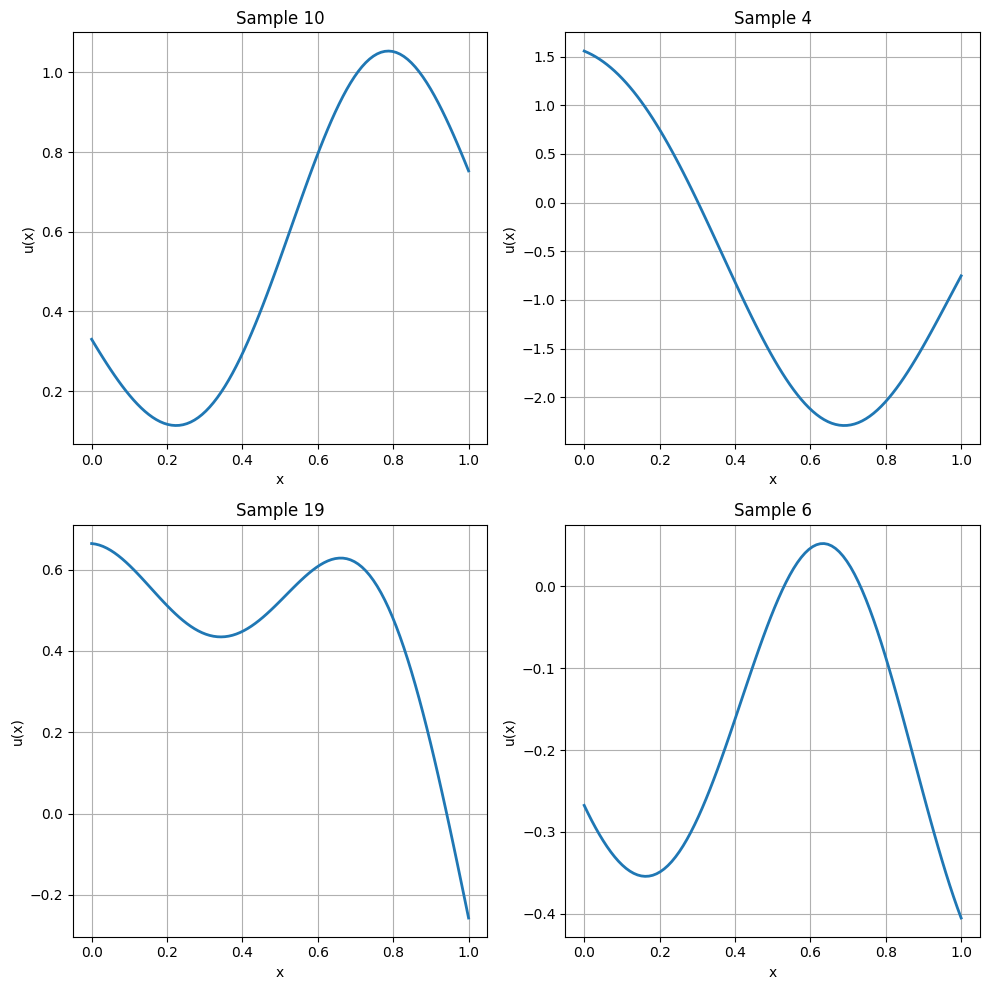

In [4]:
# Inspect a few generated function samples
length_scale = 0.4
num_samples = 20
num_points = 100

x_grid = np.linspace(0.0, 1.0, num_points).reshape(-1, 1)
sampled_functions = generate_gp_samples(length_scale=length_scale, num_samples=num_samples, num_points=num_points)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

selected_indices = np.random.choice(num_samples, size=4, replace=False)

for plot_idx, sample_idx in enumerate(selected_indices):
    ax = axes[plot_idx // 2, plot_idx % 2]
    ax.plot(x_grid, sampled_functions[sample_idx], linewidth=2)
    ax.set_title(f"Sample {sample_idx}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### 2. Organize dataset for PI-DeepONet

In [5]:
def generate_deeponet_dataset(
    num_functions,
    length_scale,
    ode_coefficient_a,
    ode_coefficient_b,
    solve_ode=False,
    num_time_points=100,
    time_interval=(0.0, 1.0),
):
    """
    Generate a dataset for Physics-Informed DeepONet training.

    Each training sample consists of:
    - a time coordinate t,
    - the full input function u(.), sampled on a fixed grid,
    - the local value u(t).

    Optionally, the function also computes the corresponding ODE solution s(t)
    for each sampled input function.

    Parameters
    ----------
    num_functions : int
        Number of random input functions u(.) to generate.
    length_scale : float
        Length scale of the RBF kernel used to sample the input functions.
    ode_coefficient_a : float
        Coefficient a in the ODE definition.
    ode_coefficient_b : float
        Constant term b in the ODE definition.
    solve_ode : bool, optional
        Whether to solve the ODE and return the corresponding targets.
    num_time_points : int, optional
        Number of discretization points in time.
    time_interval : tuple of float, optional
        Time domain over which the functions and ODE are evaluated.

    Returns
    -------
    features : np.ndarray of shape (num_functions * num_time_points, num_time_points + 2)
        Input matrix containing [t, u(.), u(t)] for each sample.
    targets : np.ndarray of shape (num_functions * num_time_points, 1)
        ODE solution values s(t). If solve_ode=False, this array is returned as zeros.
    """
    t_start, t_end = time_interval
    time_grid = np.linspace(t_start, t_end, num_time_points)
    time_grid_column = time_grid.reshape(-1, 1)

    # Sample random input functions u(.)
    function_samples = generate_gp_samples(
        length_scale=length_scale,
        num_samples=num_functions,
        num_points=num_time_points,
        domain=time_interval,
    )

    # Preallocate arrays
    num_rows = num_functions * num_time_points
    num_features = num_time_points + 2  # [t] + [u(.)] + [u(t)]
    features = np.zeros((num_rows, num_features))
    targets = np.zeros((num_rows, 1))

    for function_idx in tqdm(range(num_functions)):
        function_values = function_samples[function_idx]

        # Repeat the full function profile for each time point
        repeated_function = np.tile(function_values, (num_time_points, 1))

        # Extract u(t) along the diagonal
        function_at_t = function_values.reshape(-1, 1)

        # Assemble feature block for this function
        row_start = function_idx * num_time_points
        row_end = (function_idx + 1) * num_time_points
        features[row_start:row_end, :] = np.concatenate(
            [time_grid_column, repeated_function, function_at_t],
            axis=1,
        )

        # Optionally solve ds/dt = a * u(t) + b with s(0) = 0
        if solve_ode:
            solution = solve_ivp(
                fun=lambda current_t, current_s: (
                    ode_coefficient_a * np.interp(current_t, time_grid, function_values)
                    + ode_coefficient_b
                ),
                t_span=(t_start, t_end),
                y0=[0.0],
                t_eval=time_grid,
                method="RK45",
            )
            targets[row_start:row_end, :] = solution.y[0].reshape(-1, 1)

    return features, targets

In [6]:
# # Define ODE parameters
ode_coefficient_a = 0.5
ode_coefficient_b = 0.5

# Define dataset sizes
num_train_functions = 2000
num_val_functions = 100
num_test_functions = 100

# Define GP length scales
train_length_scale = 0.4
val_length_scale = 0.4
test_length_scale = 0.4

# Generate training dataset
X_train, y_train = generate_deeponet_dataset(
    num_functions=num_train_functions,
    length_scale=train_length_scale,
    ode_coefficient_a=ode_coefficient_a,
    ode_coefficient_b=ode_coefficient_b,
    solve_ode=True,
)

# Generate validation dataset
X_val, y_val = generate_deeponet_dataset(
    num_functions=num_val_functions,
    length_scale=val_length_scale,
    ode_coefficient_a=ode_coefficient_a,
    ode_coefficient_b=ode_coefficient_b,
    solve_ode=True,
)

# Generate test dataset
X_test, y_test = generate_deeponet_dataset(
    num_functions=num_test_functions,
    length_scale=test_length_scale,
    ode_coefficient_a=ode_coefficient_a,
    ode_coefficient_b=ode_coefficient_b,
    solve_ode=True,
)

100%|██████████| 100/100 [00:00<00:00, 587.00it/s]


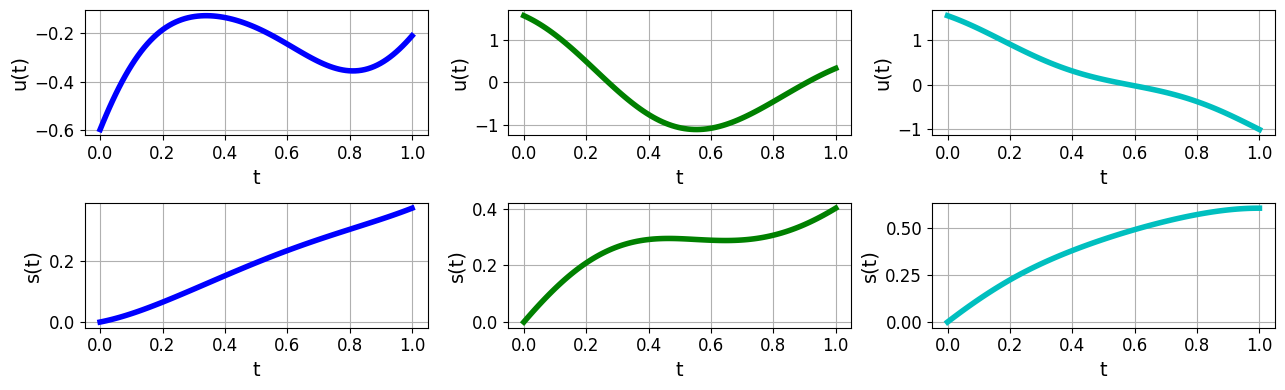

In [7]:
%matplotlib inline

# Plot a few test input functions and their corresponding ODE solutions
line_colors = ["b", "g", "c"]
num_time_points = 100
time_grid = np.linspace(0.0, 1.0, num_time_points)

fig, axes = plt.subplots(2, 3, figsize=(13, 4))

num_test_functions = y_test.shape[0] // num_time_points
selected_function_indices = np.random.choice(num_test_functions, size=3, replace=False)

for plot_col, function_idx in enumerate(selected_function_indices):
    color = line_colors[plot_col]

    # Top row: input function u(t)
    ax_top = axes[0, plot_col]
    ax_top.plot(
        time_grid,
        X_test[function_idx * num_time_points, 1:-1],
        lw=4,
        c=color,
    )
    ax_top.set_xlabel("t", fontsize=14)
    ax_top.set_ylabel("u(t)", fontsize=14)
    ax_top.tick_params(axis="both", which="major", labelsize=12)
    ax_top.grid(True)

    # Bottom row: corresponding solution s(t)
    row_start = function_idx * num_time_points
    row_end = (function_idx + 1) * num_time_points

    ax_bottom = axes[1, plot_col]
    ax_bottom.plot(
        time_grid,
        y_test[row_start:row_end, :],
        lw=4,
        c=color,
    )
    ax_bottom.set_xlabel("t", fontsize=14)
    ax_bottom.set_ylabel("s(t)", fontsize=14)
    ax_bottom.tick_params(axis="both", which="major", labelsize=12)
    ax_bottom.grid(True)

plt.tight_layout()
plt.savefig("inverse_param_sample.png", bbox_inches="tight", transparent=True)
plt.show()

#### Separate initial condition and collocation points

In [8]:
# Batch sizes
num_time_points = 100
num_train_functions = X_train.shape[0] // num_time_points

collocation_batch_size = 2000
initial_condition_batch_size = collocation_batch_size // num_time_points #num_train_functions

# Extract initial-condition samples: rows with t = 0
initial_condition_mask = X_train[:, 0] == 0.0
X_train_initial = X_train[initial_condition_mask]
y_train_initial = y_train[initial_condition_mask]

# Convert NumPy arrays to TensorFlow tensors
X_train_initial_tf = tf.convert_to_tensor(X_train_initial, dtype=tf.float32)
y_train_initial_tf = tf.convert_to_tensor(y_train_initial, dtype=tf.float32)

X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

# Create TensorFlow datasets
initial_condition_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_initial_tf, y_train_initial_tf)
)
initial_condition_dataset = initial_condition_dataset.shuffle(5000).batch(
    initial_condition_batch_size
)

collocation_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_tf, y_train_tf)
)
collocation_dataset = collocation_dataset.shuffle(100000).batch(
    collocation_batch_size
)

# Compute normalization statistics from the NumPy training data
normalization_mean = {
    "forcing": np.mean(X_train[:, 1:-1], axis=0),
    "time": np.mean(X_train[:, :1], axis=0),
}

normalization_variance = {
    "forcing": np.var(X_train[:, 1:-1], axis=0),
    "time": np.var(X_train[:, :1], axis=0),
}

### 3. Physics-informed DeepONet

#### Define a custom layer for adding a bias

In [9]:
class TrainableBias(tf.keras.layers.Layer):
    """
    A custom Keras layer that adds a single trainable scalar bias
    to every input element.
    """

    def build(self, input_shape):
        self.bias = self.add_weight(
            name="bias",
            shape=(1,),
            initializer=tf.keras.initializers.Zeros(),
            trainable=True,
        )

    def call(self, inputs):
        return inputs + self.bias

#### Define a custom layer for hosting unknown parameters

In [10]:
class TrainableODEParameters(tf.keras.layers.Layer):
    """
    Custom Keras layer that stores the scalar ODE parameters a and b
    as trainable or fixed weights.
    """

    def __init__(self, initial_a, initial_b, trainable_parameters=True, **kwargs):
        super().__init__(**kwargs)
        self.initial_a = float(initial_a)
        self.initial_b = float(initial_b)
        self.trainable_parameters = trainable_parameters

    def build(self, input_shape):
        self.a = self.add_weight(
            name="a",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.initial_a),
            trainable=self.trainable_parameters,
        )
        self.b = self.add_weight(
            name="b",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.initial_b),
            trainable=self.trainable_parameters,
        )

    def call(self, inputs):
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "initial_a": self.initial_a,
                "initial_b": self.initial_b,
                "trainable_parameters": self.trainable_parameters,
            }
        )
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

#### Define Physics-informed DeepONet

In [11]:
def build_deeponet_model(
    normalization_mean,
    normalization_variance,
    initial_a,
    initial_b,
    trainable_parameters=True,
    show_summary=False,
):
    """
    Build a DeepONet model with fully connected branch and trunk networks.

    Parameters
    ----------
    normalization_mean : dict
        Dictionary containing normalization means for the inputs:
        - "forcing": mean of the forcing/function input
        - "time": mean of the time input
    normalization_variance : dict
        Dictionary containing normalization variances for the inputs:
        - "forcing": variance of the forcing/function input
        - "time": variance of the time input
    initial_a : float
        Initial value for ODE parameter a.
    initial_b : float
        Initial value for ODE parameter b.
    trainable_parameters : bool, optional
        Whether ODE parameters a and b should be trainable.
    show_summary : bool, optional
        Whether to print the model summary.

    Returns
    -------
    model : tf.keras.Model
        DeepONet model with branch input, trunk input, scalar output,
        and attached trainable ODE parameters.
    """
    # Branch network: full input function u(.)
    branch_input = tf.keras.Input(
        shape=(len(normalization_mean["forcing"]),),
        name="forcing",
    )
    branch_features = tf.keras.layers.Normalization(
        mean=normalization_mean["forcing"],
        variance=normalization_variance["forcing"],
        name="branch_normalization",
    )(branch_input)

    for layer_idx in range(3):
        branch_features = tf.keras.layers.Dense(
            50,
            activation="tanh",
            name=f"branch_dense_{layer_idx + 1}",
        )(branch_features)

    # Trunk network: time coordinate t
    trunk_input = tf.keras.Input(
        shape=(len(normalization_mean["time"]),),
        name="time",
    )
    trunk_features = tf.keras.layers.Normalization(
        mean=normalization_mean["time"],
        variance=normalization_variance["time"],
        name="trunk_normalization",
    )(trunk_input)

    for layer_idx in range(3):
        trunk_features = tf.keras.layers.Dense(
            50,
            activation="tanh",
            name=f"trunk_dense_{layer_idx + 1}",
        )(trunk_features)

    # DeepONet merge: inner product of branch and trunk features
    merged_output = tf.keras.layers.Dot(
        axes=1,
        name="branch_trunk_dot_product",
    )([branch_features, trunk_features])

    # Add shared trainable scalar bias
    output_with_bias = TrainableBias(name="output_bias")(merged_output)

    # Attach trainable ODE parameters a and b
    output = TrainableODEParameters(
        initial_a=initial_a,
        initial_b=initial_b,
        trainable_parameters=trainable_parameters,
        name="ode_parameters",
    )(output_with_bias)

    # Build model
    model = tf.keras.Model(
        inputs=[branch_input, trunk_input],
        outputs=output,
        name="DeepONet",
    )

    if show_summary:
        model.summary()

    return model

#### ODE loss

In [12]:
@tf.function
def compute_ode_residual(time_input, forcing_input, forcing_at_time, model):
    """
    Compute the ODE residual for the Physics-Informed DeepONet.

    The governing equation is assumed to be:
        ds/dt = a * u(t) + b

    so the residual is:
        ds/dt - a * u(t) - b

    Parameters
    ----------
    time_input : tf.Tensor
        Time coordinates t.
    forcing_input : tf.Tensor
        Full input function u(.) evaluated on the discretized grid.
    forcing_at_time : tf.Tensor
        Local value u(t) corresponding to each time coordinate.
    model : tf.keras.Model
        DeepONet model.

    Returns
    -------
    residual : tf.Tensor
        Residual of the governing ODE.
    """
    with tf.GradientTape() as tape:
        tape.watch(time_input)
        predicted_solution = model(
            {
                "forcing": forcing_input,
                "time": time_input,
            }
        )

    solution_time_derivative = tape.gradient(predicted_solution, time_input)

    parameter_layer = model.get_layer("ode_parameters")
    residual = (
        solution_time_derivative
        - parameter_layer.a * forcing_at_time
        - parameter_layer.b
    )

    return residual

#### Gradient descent step

In [13]:
@tf.function
def compute_training_step(
    collocation_features,
    collocation_targets,
    initial_condition_features,
    initial_condition_weight,
    ode_residual_weight,
    data_fit_weight,
    model,
):
    """
    Compute the training losses and gradients for one optimization step.

    Parameters
    ----------
    collocation_features : tf.Tensor
        Training inputs used for the ODE residual and data-fitting terms.
    collocation_targets : tf.Tensor
        Target solution values corresponding to `collocation_features`.
    initial_condition_features : tf.Tensor
        Training inputs corresponding to the initial condition t = 0.
    initial_condition_weight : float
        Weight applied to the initial condition loss.
    ode_residual_weight : float
        Weight applied to the ODE residual loss.
    data_fit_weight : float
        Weight applied to the supervised data loss.
    model : tf.keras.Model
        DeepONet model.

    Returns
    -------
    ode_loss : tf.Tensor
        Physics residual loss.
    initial_condition_loss : tf.Tensor
        Initial condition loss.
    data_loss : tf.Tensor
        Supervised data-fitting loss.
    total_loss : tf.Tensor
        Weighted sum of all loss terms.
    gradients : list of tf.Tensor
        Gradients of `total_loss` with respect to trainable model parameters.
    """
    with tf.GradientTape() as tape:
        # Initial condition prediction: s(0) should be zero
        initial_condition_prediction = model(
            {
                "forcing": initial_condition_features[:, 1:-1],
                "time": initial_condition_features[:, :1],
            }
        )

        # ODE residual at collocation points
        ode_residual = compute_ode_residual(
            time_input=collocation_features[:, :1],
            forcing_input=collocation_features[:, 1:-1],
            forcing_at_time=collocation_features[:, -1:],
            model=model,
        )

        # Supervised prediction on collocation/data points
        data_prediction = model(
            {
                "forcing": collocation_features[:, 1:-1],
                "time": collocation_features[:, :1],
            }
        )

        # Individual loss terms
        initial_condition_loss = tf.reduce_mean(tf.square(initial_condition_prediction))
        ode_loss = tf.reduce_mean(tf.square(ode_residual))
        data_loss = tf.reduce_mean(tf.square(collocation_targets - data_prediction))

        # Total weighted loss
        total_loss = (
            initial_condition_weight * initial_condition_loss
            + ode_residual_weight * ode_loss
            + data_fit_weight * data_loss
        )

    gradients = tape.gradient(total_loss, model.trainable_variables)

    return ode_loss, initial_condition_loss, data_loss, total_loss, gradients

#### Define Loss Tracking class

In [14]:
class LossTracker:
    def __init__(self):
        self.total_loss_metric = keras.metrics.Mean(name="total_loss")
        self.initial_condition_loss_metric = keras.metrics.Mean(name="initial_condition_loss")
        self.ode_loss_metric = keras.metrics.Mean(name="ode_loss")
        self.data_loss_metric = keras.metrics.Mean(name="data_loss")

        self.loss_history = defaultdict(list)

    def update(self, total_loss, initial_condition_loss, ode_loss, data_loss):
        self.total_loss_metric.update_state(total_loss)
        self.initial_condition_loss_metric.update_state(initial_condition_loss)
        self.ode_loss_metric.update_state(ode_loss)
        self.data_loss_metric.update_state(data_loss)

    def reset(self):
        self.total_loss_metric.reset_state()
        self.initial_condition_loss_metric.reset_state()
        self.ode_loss_metric.reset_state()
        self.data_loss_metric.reset_state()

    def log_history(self):
        self.loss_history["total_loss"].append(self.total_loss_metric.result().numpy())
        self.loss_history["initial_condition_loss"].append(
            self.initial_condition_loss_metric.result().numpy()
        )
        self.loss_history["ode_loss"].append(self.ode_loss_metric.result().numpy())
        self.loss_history["data_loss"].append(self.data_loss_metric.result().numpy())

    def print_current(self):
        print(
            f"IC={self.initial_condition_loss_metric.result().numpy():.4e}, "
            f"ODE={self.ode_loss_metric.result().numpy():.4e}, "
            f"data={self.data_loss_metric.result().numpy():.4e}, "
            f"total_loss={self.total_loss_metric.result().numpy():.4e}"
        )

#### Define callback

In [15]:
class PrintODEParameters(keras.callbacks.Callback):
    """
    Keras callback that prints the current values of the trainable
    ODE parameters a and b at the end of each epoch.
    """

    def on_epoch_end(self, epoch, logs=None):
        parameter_layer = self.model.get_layer("ode_parameters")
        a_value = parameter_layer.a.numpy().item()
        b_value = parameter_layer.b.numpy().item()

        print(f"\na = {a_value:.6f}, b = {b_value:.6f}")

#### Training

In [16]:
# Training configuration
num_epochs = 100

initial_condition_weight = tf.constant(1.0, dtype=tf.float32)
ode_residual_weight = tf.constant(1.0, dtype=tf.float32)
data_fit_weight = tf.constant(1.0, dtype=tf.float32)

loss_tracker = LossTracker()
validation_loss_history = []
a_history = []
b_history = []

# Initial guesses for unknown ODE parameters
initial_a_guess = 0.2
initial_b_guess = 0.8

# Store predictions for one selected test profile across epochs
tracked_test_function_index = 25
tracked_test_predictions = []

# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

with tf.device("/CPU:0"):

    # Build and compile model
    deeponet_model = build_deeponet_model(
        normalization_mean=normalization_mean,
        normalization_variance=normalization_variance,
        initial_a=initial_a_guess,
        initial_b=initial_b_guess,
        trainable_parameters=True,
    )
    deeponet_model.compile(optimizer=optimizer)

    # Callbacks
    callback_list = tf.keras.callbacks.CallbackList(
        [
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=30,
            ),
            keras.callbacks.ModelCheckpoint(
                filepath="NN_model.h5",
                monitor="val_loss",
                save_best_only=True,
            ),
            PrintODEParameters(),
        ],
        add_history=False,
        model=deeponet_model,
    )

    callback_list.on_train_begin()

    # Training loop
    for epoch_idx in range(num_epochs):
        print(f"Epoch {epoch_idx + 1}:")
        callback_list.on_epoch_begin(epoch_idx)

        for (initial_batch_features, _), (collocation_batch_features, collocation_batch_targets) in zip(
            initial_condition_dataset,
            collocation_dataset,
        ):
            ode_loss, initial_condition_loss, data_loss, total_loss, gradients = compute_training_step(
                collocation_features=collocation_batch_features,
                collocation_targets=collocation_batch_targets,
                initial_condition_features=initial_batch_features,
                initial_condition_weight=initial_condition_weight,
                ode_residual_weight=ode_residual_weight,
                data_fit_weight=data_fit_weight,
                model=deeponet_model,
            )

            deeponet_model.optimizer.apply_gradients(
                zip(gradients, deeponet_model.trainable_variables)
            )

            loss_tracker.update(
                total_loss=total_loss,
                initial_condition_loss=initial_condition_loss,
                ode_loss=ode_loss,
                data_loss=data_loss,
            )

        # Record and print epoch losses
        loss_tracker.log_history()
        loss_tracker.print_current()

        # Record parameter values
        parameter_layer = deeponet_model.get_layer("ode_parameters")
        a_history.append(parameter_layer.a.numpy().item())
        b_history.append(parameter_layer.b.numpy().item())

        # Validation
        validation_predictions = deeponet_model.predict(
            {
                "forcing": X_val[:, 1:-1],
                "time": X_val[:, :1],
            },
            batch_size=12800,
            verbose=0,
        )
        validation_loss = tf.reduce_mean(tf.square(y_val - validation_predictions))
        current_learning_rate = float(
            tf.keras.backend.get_value(deeponet_model.optimizer.learning_rate)
        )

        print(
            f"val_loss: {float(validation_loss):.4e}, "
            f"lr: {current_learning_rate:.2e}"
        )

        callback_list.on_epoch_end(
            epoch_idx,
            logs={"val_loss": float(validation_loss)},
        )
        validation_loss_history.append(float(validation_loss))

        # Test evaluation
        test_predictions = deeponet_model.predict(
            {
                "forcing": X_test[:, 1:-1],
                "time": X_test[:, :1],
            },
            batch_size=12800,
            verbose=0,
        )
        test_rmse = np.sqrt(mean_squared_error(y_test.flatten(), test_predictions.flatten()))
        print(f"test_RMSE: {test_rmse:.6e}")

        # Track one specific test profile across epochs
        row_start = tracked_test_function_index * num_time_points
        row_end = (tracked_test_function_index + 1) * num_time_points

        tracked_prediction = deeponet_model.predict(
            {
                "forcing": X_test[row_start:row_end, 1:-1],
                "time": X_test[row_start:row_end, :1],
            },
            batch_size=12800,
            verbose=0,
        )
        tracked_test_predictions.append(tracked_prediction)

        # Reset metrics for the next epoch
        loss_tracker.reset()

    callback_list.on_train_end()

Epoch 1:
IC=3.3831e-02, ODE=1.2031e-01, data=3.9440e-02, total_loss=1.9358e-01


val_loss: 1.8194e-02, lr: 1.00e-03

a = 0.195176, b = 0.750843
test_RMSE: 1.299191e-01
Epoch 2:


IC=6.0076e-03, ODE=1.1200e-02, data=1.3508e-02, total_loss=3.0716e-02
val_loss: 1.1705e-02, lr: 1.00e-03

a = 0.242096, b = 0.724960
test_RMSE: 1.052635e-01
Epoch 3:


IC=4.1218e-03, ODE=5.7818e-03, data=9.5313e-03, total_loss=1.9435e-02
val_loss: 7.7868e-03, lr: 1.00e-03

a = 0.296753, b = 0.700468
test_RMSE: 8.556363e-02
Epoch 4:


IC=2.7979e-03, ODE=4.6687e-03, data=6.7015e-03, total_loss=1.4168e-02
val_loss: 6.5845e-03, lr: 1.00e-03

a = 0.342452, b = 0.676174
test_RMSE: 7.875062e-02
Epoch 5:


...

IC=2.2648e-06, ODE=6.7679e-05, data=7.8339e-06, total_loss=7.7778e-05
val_loss: 9.0248e-06, lr: 2.50e-04

a = 0.498633, b = 0.499982
test_RMSE: 2.383157e-03
Epoch 89:


IC=2.5557e-06, ODE=6.3345e-05, data=5.9743e-06, total_loss=7.1875e-05
val_loss: 8.0092e-06, lr: 2.50e-04

a = 0.498667, b = 0.499951
test_RMSE: 2.179222e-03
Epoch 90:
IC=4.2280e-06, ODE=7.9334e-05, data=1.0515e-05, total_loss=9.4077e-05
val_loss: 1.3831e-05, lr: 2.50e-04

a = 0.498611, b = 0.499925
test_RMSE: 2.690269e-03
Epoch 91:


IC=2.9282e-06, ODE=6.8392e-05, data=8.8356e-06, total_loss=8.0156e-05
val_loss: 7.9744e-06, lr: 2.50e-04

a = 0.498669, b = 0.499922
test_RMSE: 2.786353e-03
Epoch 92:
IC=2.7780e-06, ODE=7.3797e-05, data=9.2774e-06, total_loss=8.5852e-05
val_loss: 1.0004e-05, lr: 2.50e-04

a = 0.498685, b = 0.499902
test_RMSE: 3.028663e-03
Epoch 93:
IC=2.7729e-06, ODE=6.9406e-05, data=7.3599e-06, total_loss=7.9539e-05
val_loss: 9.7373e-06, lr: 2.50e-04

a = 0.498714, b = 0.499894
test_RMSE: 2.918810e-03
Epoch 94:
IC=2.9038e-06, ODE=6.9776e-05, data=9.0975e-06, total_loss=8.1777e-05
val_loss: 1.2131e-05, lr: 2.50e-04

a = 0.498674, b = 0.500074
test_RMSE: 2.565242e-03
Epoch 95:
IC=3.1644e-06, ODE=7.0090e-05, data=8.7230e-06, total_loss=8.1978e-05
val_loss: 9.9458e-06, lr: 2.50e-04

a = 0.498686, b = 0.499940
test_RMSE: 2.169840e-03
Epoch 96:


IC=2.4570e-06, ODE=6.3698e-05, data=6.6954e-06, total_loss=7.2851e-05
val_loss: 7.4039e-06, lr: 2.50e-04

a = 0.498707, b = 0.499979
test_RMSE: 2.207936e-03
Epoch 97:
IC=4.5139e-06, ODE=1.0238e-04, data=1.6094e-05, total_loss=1.2298e-04
val_loss: 1.6282e-05, lr: 2.50e-04

a = 0.498573, b = 0.499748
test_RMSE: 3.370439e-03
Epoch 98:
IC=3.8683e-06, ODE=6.2201e-05, data=6.0693e-06, total_loss=7.2139e-05
val_loss: 7.6509e-06, lr: 2.50e-04

a = 0.498720, b = 0.499963
test_RMSE: 2.182397e-03
Epoch 99:
IC=3.1196e-06, ODE=5.6942e-05, data=5.9387e-06, total_loss=6.6000e-05
val_loss: 1.8096e-05, lr: 2.50e-04

a = 0.498819, b = 0.499964
test_RMSE: 3.537566e-03
Epoch 100:


IC=2.5433e-06, ODE=6.4026e-05, data=6.0314e-06, total_loss=7.2601e-05
val_loss: 7.1346e-06, lr: 2.50e-04

a = 0.498838, b = 0.499969
test_RMSE: 2.385268e-03


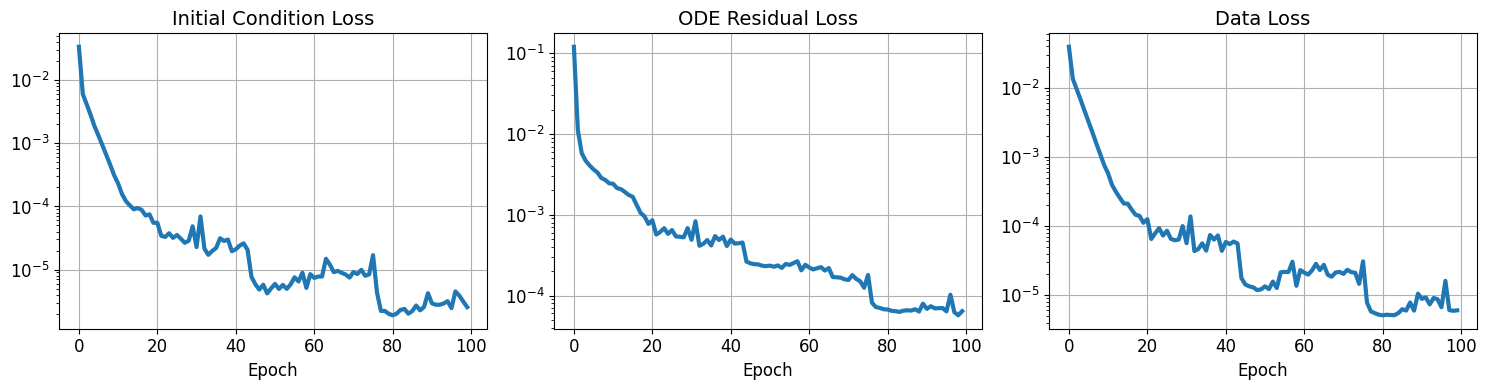

In [17]:
# Loss history
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(num_epochs), loss_tracker.loss_history["initial_condition_loss"], lw=3)
axes[1].plot(range(num_epochs), loss_tracker.loss_history["ode_loss"], lw=3)
axes[2].plot(range(num_epochs), loss_tracker.loss_history["data_loss"], lw=3)

axes[0].set_title("Initial Condition Loss", fontsize=14)
axes[1].set_title("ODE Residual Loss", fontsize=14)
axes[2].set_title("Data Loss", fontsize=14)

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)

plt.tight_layout()
plt.savefig("loss.png", bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()

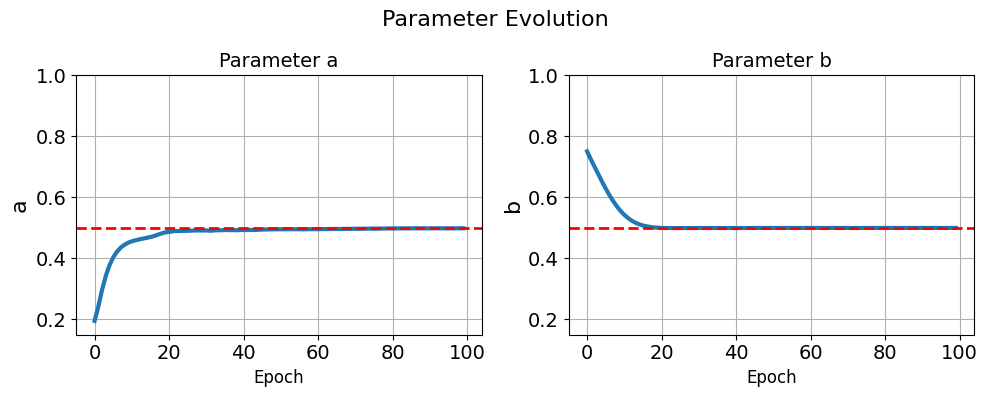

In [18]:
# Parameter history
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(num_epochs), a_history, lw=3)
axes[0].set_ylabel("a", fontsize=16)
axes[0].set_title("Parameter a", fontsize=14)

axes[1].plot(range(num_epochs), b_history, lw=3)
axes[1].set_ylabel("b", fontsize=16)
axes[1].set_title("Parameter b", fontsize=14)

for ax in axes:
    ax.set_xlabel("Epoch", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.set_ylim((0.15, 1.0))
    ax.grid(True)
    ax.axhline(y=0.5, color="r", linestyle="--", linewidth=2)

fig.suptitle("Parameter Evolution", fontsize=16)
plt.tight_layout()
plt.savefig("inverse_param_estimate.png", bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()